# EDA и очистка HTML

Я проверяю структуру данных, распределение меток и варианты очистки. В финале сохраняю полезные HTML-поля отдельно.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path(".")
DATA_DIR = ROOT / "statement" / "candidate_public" / "candidate_data"
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import json

import matplotlib.pyplot as plt

from data import load_data, read_feather

articles_raw = read_feather(DATA_DIR / "articles.f")
articles, calibration, _ = load_data(DATA_DIR)
summary = json.loads((ROOT / "outputs/dataset_summary.json").read_text())
summary

{'articles': 793,
 'calibration_queries': 500,
 'test_queries': 500,
 'labeled_articles': 79,
 'unseen_articles': 714,
 'average_labels_per_query': 1.5219999551773071,
 'multilabel_queries': 221,
 'singleton_labeled_articles': 40,
 'median_article_length': 2166.0,
 'median_query_length': 67.0}

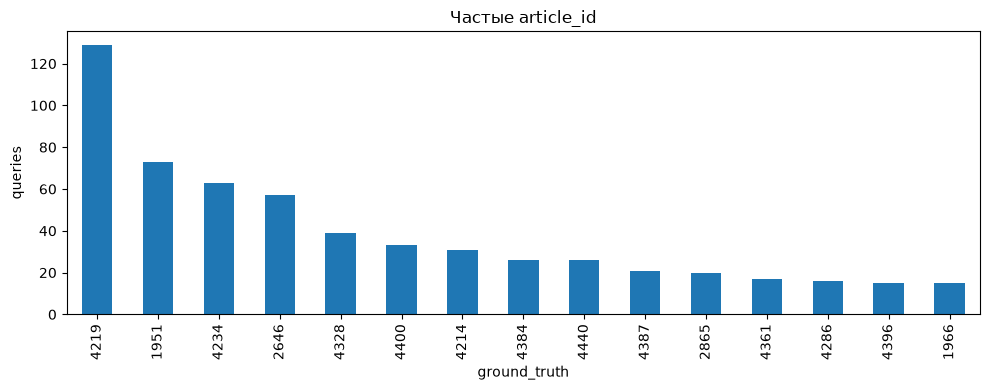

In [3]:
label_counts = calibration["ground_truth"].str.split().explode().value_counts()
label_counts.head(15).plot(kind="bar", figsize=(10, 4), title="Частые article_id")
plt.ylabel("queries")
plt.tight_layout()

In [4]:
pd.DataFrame(
    {
        "raw_html": articles_raw["body"].str.len().describe(),
        "visible_text": articles["body_clean"].str.len().describe(),
    }
).round(1)

,raw_html,visible_text
count,793.0,793.0
mean,8538.2,4965.8
std,33793.7,19032.9
min,31.0,24.0
25%,1780.0,1116.0
50%,3513.0,2166.0
75%,7887.0,4554.0
max,901357.0,506083.0


In [5]:
cleaning = pd.read_csv(ROOT / "outputs/cleaning_results.csv")
cleaning.sort_values("MAP@10", ascending=False)

,cleaning,MAP@10,selected,decision
5,stemmed_full,0.318739,True,Использую как дополнительное представление
4,weighted_headings,0.283765,True,Использую заголовки как отдельное поле
3,visible_full,0.281731,True,Использую основной текст без тегов
2,visible_15k,0.272439,False,Не использую: теряю часть полезного текста
1,raw_html,0.266124,False,Не использую: служебные теги создают шум
0,visible_5k,0.237348,False,Не использую: слишком сильно обрезаю текст


**Решение:** удаляю служебные теги, но сохраняю структуру в отдельных полях. Полный видимый текст не обрезаю; stemming использую как дополнительный сигнал.

> Для сохранения submission я раскомментирую и выполняю следующую клетку.

In [6]:
# from pipeline import fit_predict

# answer = fit_predict(DATA_DIR)
# OUTPUT_PATH = ROOT / "outputs" / "answer.csv"
# answer.to_csv(OUTPUT_PATH, index=False)
# OUTPUT_PATH